Chuẩn bị dữ liệu

In [12]:
import numpy as np
import os

BASE_DIR = "/content/drive/MyDrive"

path = os.path.join(BASE_DIR, "processed_data.npz")
data = np.load(path)

x_train = data["x_train"]
y_train = data["y_train"]
y_train_onehot = data["y_train_onehot"]

x_val = data["x_val"]
y_val = data["y_val"]
y_val_onehot = data["y_val_onehot"]

x_test = data["x_test"]
y_test = data["y_test"]
y_test_onehot = data["y_test_onehot"]

print("Loaded shapes:")
print("Train :", x_train.shape, y_train.shape, y_train_onehot.shape)
print("Val   :", x_val.shape,   y_val.shape,   y_val_onehot.shape)
print("Test  :", x_test.shape,  y_test.shape,  y_test_onehot.shape)


Loaded shapes:
Train : (50000, 28, 28) (50000,) (50000, 10)
Val   : (10000, 28, 28) (10000,) (10000, 10)
Test  : (10000, 28, 28) (10000,) (10000, 10)


Khởi tạo Softmax implementation

In [2]:
def softmax(z):
    z = z - np.max(z, axis=1, keepdims=True)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)


In [5]:
def cross_entropy(y_true, y_prob):
    eps = 1e-12
    return -np.mean(np.sum(y_true * np.log(y_prob + eps), axis=1))


In [6]:
x_train = data["x_train"].reshape(50000, -1)
x_val   = data["x_val"].reshape(10000, -1)
x_test  = data["x_test"].reshape(10000, -1)

y_train = data["y_train"]
y_val   = data["y_val"]
y_test  = data["y_test"]

y_train_oh = data["y_train_onehot"]
y_val_oh   = data["y_val_onehot"]
y_test_oh  = data["y_test_onehot"]


In [7]:
num_features = x_train.shape[1]
num_classes  = 10

W = np.zeros((num_features, num_classes))
b = np.zeros((num_classes,))


In [10]:
def predict_prob(X):
    return softmax(X @ W + b)

def predict(X):
    return np.argmax(predict_prob(X), axis=1)

num_features = x_train.shape[1]
num_classes  = 10

W = np.zeros((num_features, num_classes))
b = np.zeros(num_classes)

lr = 0.1
epochs = 180
lambda_l2 = 0.001

for epoch in range(1, epochs + 1):
    y_prob = predict_prob(x_train)

    loss = cross_entropy(y_train_oh, y_prob) + (lambda_l2 / 2) * np.sum(W * W)

    grad_W = (x_train.T @ (y_prob - y_train_oh)) / len(x_train) + lambda_l2 * W
    grad_b = np.mean(y_prob - y_train_oh, axis=0)

    W -= lr * grad_W
    b -= lr * grad_b

    if epoch % 10 == 0:
        val_acc = (predict(x_val) == y_val).mean()
        print(f"Epoch {epoch:3d} | Loss={loss:.4f} | Val Acc={val_acc:.4f}")

train_acc = (predict(x_train) == y_train).mean()
val_acc   = (predict(x_val) == y_val).mean()
test_acc  = (predict(x_test) == y_test).mean()

print("Train accuracy :", train_acc)
print("Val accuracy   :", val_acc)
print("Test accuracy  :", test_acc)


Epoch  10 | Loss=1.5996 | Val Acc=0.7784
Epoch  20 | Loss=1.2144 | Val Acc=0.8093
Epoch  30 | Loss=1.0115 | Val Acc=0.8241
Epoch  40 | Loss=0.8892 | Val Acc=0.8330
Epoch  50 | Loss=0.8075 | Val Acc=0.8402
Epoch  60 | Loss=0.7490 | Val Acc=0.8445
Epoch  70 | Loss=0.7048 | Val Acc=0.8501
Epoch  80 | Loss=0.6701 | Val Acc=0.8540
Epoch  90 | Loss=0.6420 | Val Acc=0.8574
Epoch 100 | Loss=0.6188 | Val Acc=0.8605
Epoch 110 | Loss=0.5992 | Val Acc=0.8625
Epoch 120 | Loss=0.5825 | Val Acc=0.8649
Epoch 130 | Loss=0.5680 | Val Acc=0.8666
Epoch 140 | Loss=0.5552 | Val Acc=0.8687
Epoch 150 | Loss=0.5439 | Val Acc=0.8694
Epoch 160 | Loss=0.5339 | Val Acc=0.8700
Epoch 170 | Loss=0.5248 | Val Acc=0.8708
Epoch 180 | Loss=0.5166 | Val Acc=0.8723
Train accuracy : 0.87492
Val accuracy   : 0.8723
Test accuracy  : 0.884


Hàm tạo Confusion Matrix

In [ ]:
import numpy as np

def confusion_matrix(y_true, y_pred, num_classes=10):
    cm = np.zeros((num_classes, num_classes), dtype=int)

    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1

    return cm


Hàm vẽ Confusion Matrix

In [ ]:
def plot_confusion_matrix(cm, labels=None, normalize=False):
    if labels is None:
        labels = list(range(cm.shape[0]))

    if normalize:
        cm = cm / cm.sum(axis=1, keepdims=True)

    plt.figure(figsize=(6, 6))
    plt.imshow(cm, interpolation='nearest')
    plt.title("Confusion Matrix" + (" (normalized)" if normalize else ""))
    plt.colorbar()

    tick_marks = np.arange(len(labels))
    plt.xticks(tick_marks, labels)
    plt.yticks(tick_marks, labels)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            text = f"{cm[i,j]:.2f}" if normalize else str(cm[i,j])
            plt.text(j, i, text, ha="center", va="center")

    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.tight_layout()
    plt.show()


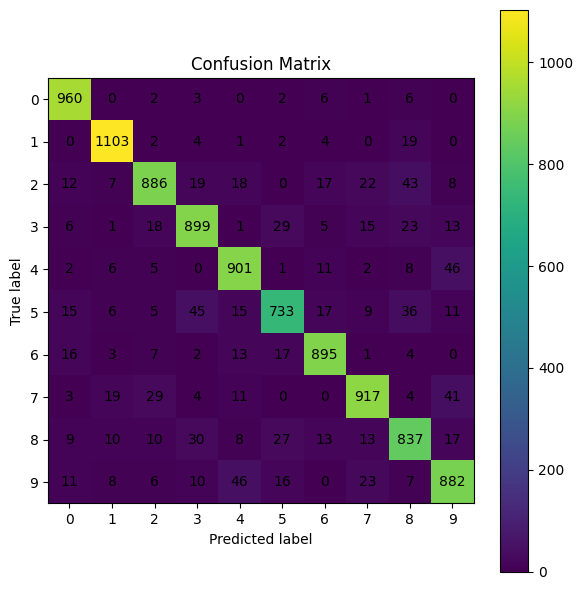

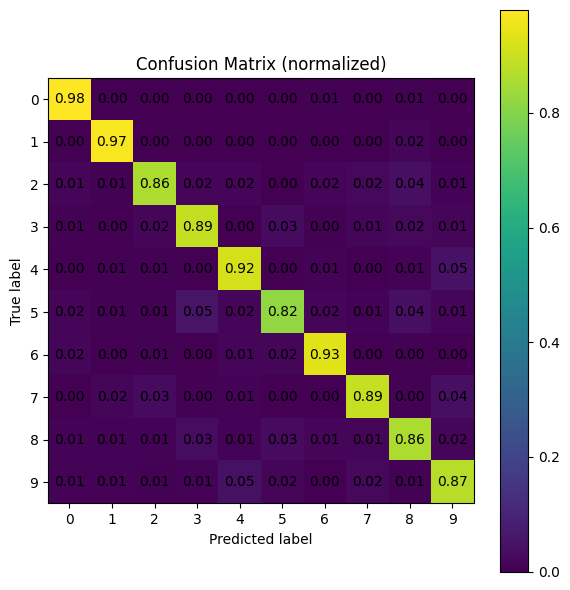

In [ ]:
cm = confusion_matrix(y_true, y_pred, num_classes=10)

plot_confusion_matrix(cm)
plot_confusion_matrix(cm, normalize=True)


In ra TOP 5 cặp nhầm nhiều nhất




In [ ]:
def print_confused_pairs(cm, top_k=5):
    cm = np.array(cm)

    pairs = []

    for true_digit in range(cm.shape[0]):
        for pred_digit in range(cm.shape[1]):
            if true_digit != pred_digit:
                pairs.append((cm[true_digit, pred_digit], true_digit, pred_digit))

    pairs.sort(reverse=True, key=lambda x: x[0])

    print(f"Top {top_k} cặp nhầm nhiều nhất")
    for count, t, p in pairs[:top_k]:
        print(f"  {t} → {p} : {count} samples")


In [ ]:
cm = confusion_matrix(y_true, y_pred, num_classes=10)
print_confused_pairs(cm, top_k=5)


Top 5 confused digit pairs:
  4 → 9 : 46 samples
  9 → 4 : 46 samples
  5 → 3 : 45 samples
  2 → 8 : 43 samples
  7 → 9 : 41 samples


Xem các trường hợp dự đoán sai (misclassified)

Found 987 misclassified samples


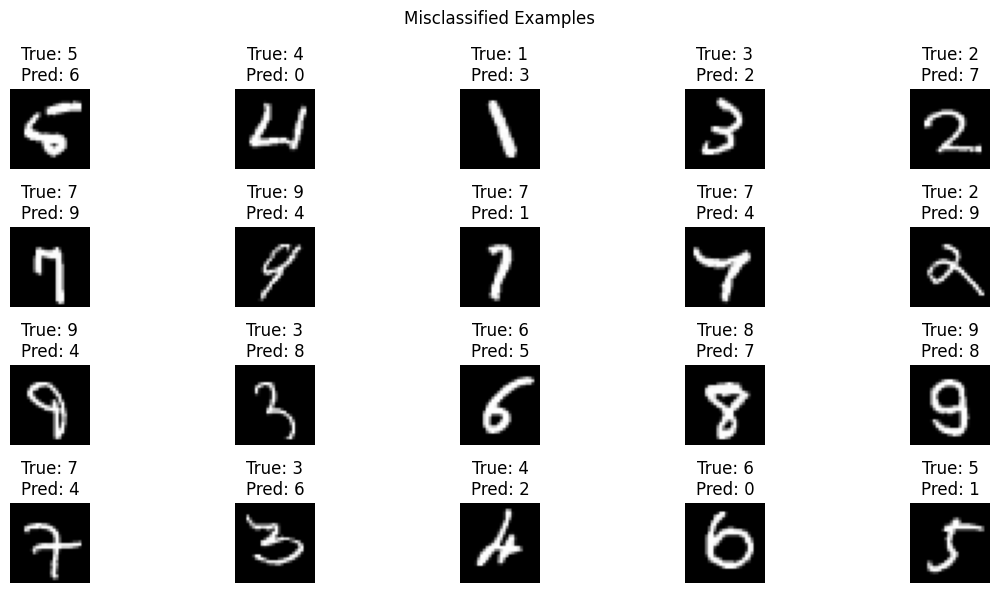

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def show_misclassified(X, y_true, y_pred, n=20):
    if X.ndim == 2:
        X_show = X.reshape(-1, 28, 28)
    else:
        X_show = X

    wrong_idx = np.where(y_true != y_pred)[0]

    print(f"Tìm thấy {len(wrong_idx)} misclassified samples")

    n = min(n, len(wrong_idx))

    plt.figure(figsize=(12, 6))

    for i, idx in enumerate(wrong_idx[:n]):
        plt.subplot(4, 5, i + 1)
        plt.imshow(X_show[idx], cmap="gray")
        plt.title(f"True: {y_true[idx]}\nPred: {y_pred[idx]}")
        plt.axis("off")

    plt.suptitle("Misclassified Examples")
    plt.tight_layout()
    plt.show()

# gọi hàm
y_true = y_test
y_pred = predict(x_test)

show_misclassified(x_test, y_true, y_pred, n=20)


LỌC RIÊNG MỘT CẶP LỖI

Found 45 samples where 5 → predicted 3


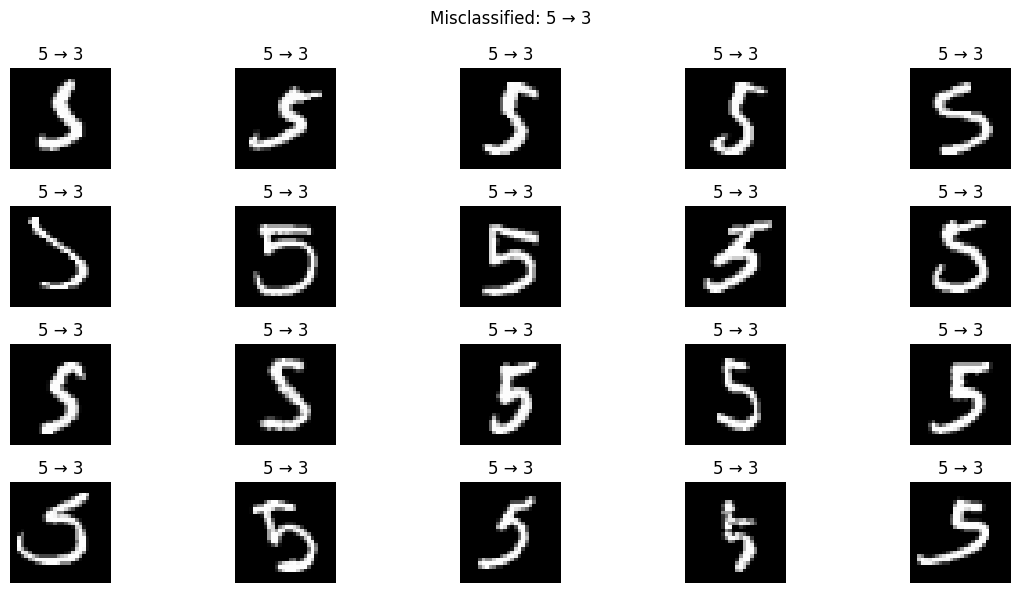

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def show_pair_errors(X, y_true, y_pred, true_label, pred_label, n=20):
    if X.ndim == 2:
        X_show = X.reshape(-1, 28, 28)
    else:
        X_show = X

    idx = np.where((y_true == true_label) & (y_pred == pred_label))[0]
    print(f"Tìm thấy {len(idx)} cặp nơi mà {true_label} → dự đoán thành {pred_label}")

    n = min(n, len(idx))
    if n == 0:
        print("No examples ")
        return

    plt.figure(figsize=(12, 6))
    for i, k in enumerate(idx[:n]):
        plt.subplot(4, 5, i + 1)
        plt.imshow(X_show[k], cmap="gray")
        plt.title(f"{true_label} → {pred_label}")
        plt.axis("off")

    plt.suptitle(f"Misclassified: {true_label} → {pred_label}")
    plt.tight_layout()
    plt.show()

show_pair_errors(x_test, y_test, predict(x_test), true_label=5, pred_label=3)


PHÂN TÍCH: VÌ SAO MÔ HÌNH NHẦM?
 - (5 → 3): phần “bụng” của số 5 mỏng hoặc không rõ, nét trên cùng bị gãy/thiếu, trông giống số 3 cong tròn

-> Softmax (linear model) chỉ “nhìn” pixel thẳng — khó tách khi nét giống nhau.

- (4 → 9): nét dọc của 4 bị kéo cong, góc trên bên phải bị nối lại → giống 9, chữ bị viết lệch / nghiêng

-> Vì 4 và 9 có cấu trúc giống nhau nếu nét không dứt khoát.
- (7 → 1):số 7 không có gạch ngang, viết thẳng giống hệt 1

-> Các biến thể chữ viết tay làm Softmax “không đủ biểu diễn”.

- (8 → 3): vòng dưới 8 nhỏ, vòng trên đậm → giống 3

-> Mô hình tuyến tính khó phân biệt “hai vòng” vs “một vòng”.

- Ý nghĩa rút ra

Softmax thuần: tuyến tính → không học được dạng hình phức tạp, nhạy với nhiễu, lệch, mờ, dễ nhầm các chữ có cấu trúc tương tự

## So sánh với Sklearn Implementation

In [ ]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(
    multi_class="multinomial",
    solver="saga",
    penalty="l2",
    C=1.0,
    max_iter=200,
    n_jobs=-1
)

clf.fit(x_train, y_train)

sk_train_acc = clf.score(x_train, y_train)
sk_val_acc   = clf.score(x_val, y_val)
sk_test_acc  = clf.score(x_test, y_test)

print("Sklearn Softmax")
print("Train :", sk_train_acc)
print("Val   :", sk_val_acc)
print("Test  :", sk_test_acc)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Sklearn Softmax
Train : 0.94072
Val   : 0.9195
Test  : 0.9256


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [ ]:
print("\nACCURACY COMPARISON")
print("----------------------------------------------")
print(f"{'Model':12} | {'Train':>8} | {'Val':>8} | {'Test':>8}")
print("----------------------------------------------")
print(f"{'My Softmax':12} | {train_acc:8.4f} | {val_acc:8.4f} | {test_acc:8.4f}")
print(f"{'Sklearn':12}   | {sk_train_acc:8.4f} | {sk_val_acc:8.4f} | {sk_test_acc:8.4f}")
print("----------------------------------------------")



ACCURACY COMPARISON
----------------------------------------------
Model        |    Train |      Val |     Test
----------------------------------------------
My Softmax   |   0.8749 |   0.8723 |   0.8840


NameError: name 'sk_train_acc' is not defined

Dùng cùng confusion matrix để so sánh lỗi

My model


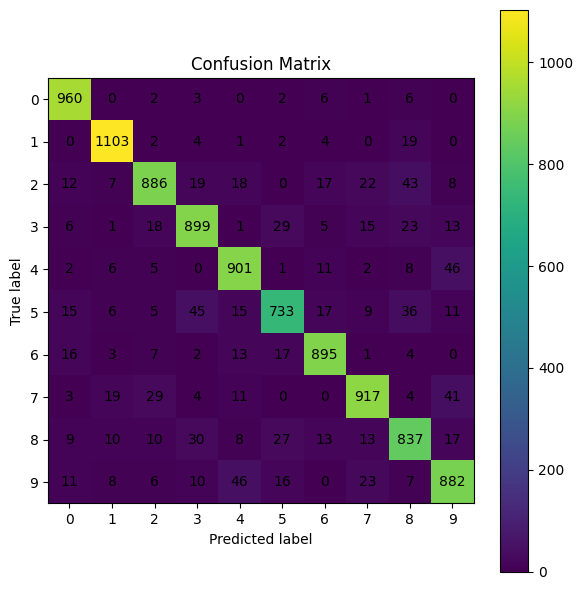

Sklearn


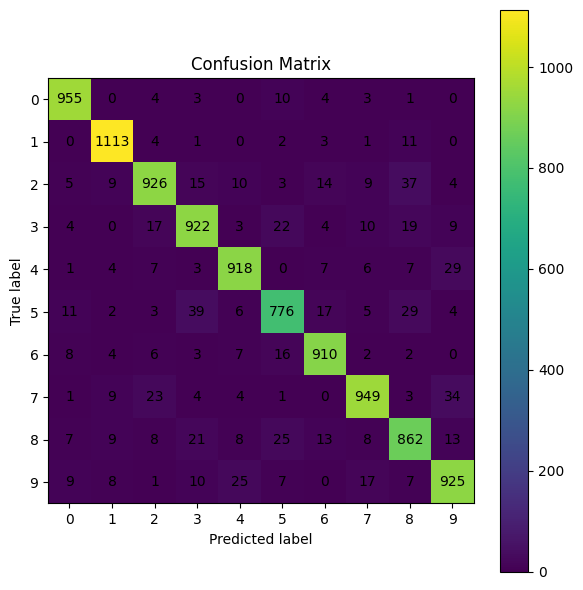

In [ ]:
y_pred_my   = predict(x_test)
y_pred_sklearn = clf.predict(x_test)

cm_my = confusion_matrix(y_test, y_pred_my, num_classes=10)
cm_sk = confusion_matrix(y_test, y_pred_sklearn, num_classes=10)

print("My model")
plot_confusion_matrix(cm_my)

print("Sklearn")
plot_confusion_matrix(cm_sk)


Lưu model Softmax tự cài (lưu W, b)

In [ ]:
import pickle

softmax_model = {
    "W": W,
    "b": b
}

with open("my_softmax.pkl", "wb") as f:
    pickle.dump(softmax_model, f)

print("Saved my_softmax.pkl")


Saved my_softmax.pkl


 Load lại để dùng:

In [ ]:
import pickle

with open("my_softmax.pkl", "rb") as f:
    softmax_model = pickle.load(f)

W = softmax_model["W"]
b = softmax_model["b"]
